# Training a GPT-style Language Model

In the previous notebook we assembled the full encoder–decoder Transformer. But assembling an architecture is not the same as having a *language model* — the weights are still random, so the model generates random tokens. This notebook turns that architecture into a working LM by **training** it.

We focus on the **GPT-style decoder-only** variant from Chapter 4, which is the architecture behind modern LLMs. The training corpus is **the-verdict.txt** — a ~3,600-word short story by Edith Wharton, the same text used in our tokenization chapter.

By the end of this notebook we will have a model that, starting from random weights, drops its training loss from **11.02 to 3.21** over 50 epochs and generates recognizable fragments of the source text — complete words, sensible punctuation, quoted dialogue, and even entities like *Mrs. Gisburn* and *the Riv[iera]* that only appear in the story. The corpus is tiny and the model overfits noticeably, but every mechanical piece of real LM training is on display.

### What we will cover

1. **Loading and tokenizing** the corpus with GPT-2 BPE
2. **Batching** via a sliding-window dataset and a PyTorch `DataLoader`
3. **Train/validation split** so we can measure generalization
4. **Model + optimizer setup** (`AdamW`, cosine LR schedule with warmup, gradient clipping)
5. **The core training loop** — forward, loss, backward, step
6. **Cross-entropy loss and perplexity** — the standard LM metrics
7. **Training** for several epochs and plotting the loss curves
8. **Generating text** before vs. after training
9. **Checkpointing** — saving and loading model weights

---

## 1. Setup

In [1]:
from importlib.metadata import version

print("torch version:", version("torch"))
print("tiktoken version:", version("tiktoken"))
print("matplotlib version:", version("matplotlib"))
print("numpy version:", version("numpy"))

torch version: 2.5.1
tiktoken version: 0.7.0
matplotlib version: 3.10.8
numpy version: 1.26.4


In [2]:
import math
import os
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import tiktoken
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

torch.manual_seed(123)
np.random.seed(123)

# Prefer GPU/MPS if available; fall back to CPU. This notebook is designed to
# finish in a few minutes on CPU with the defaults below.
if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")

print(f"Using device: {DEVICE}")

Using device: mps


---

## 2. Loading the Corpus

We use **the-verdict.txt** from Chapter 1 (`01_llm_tokenizer/`). It is a short, self-contained text — perfect for demonstrating training end-to-end on a laptop. A *real* language model is trained on hundreds of billions of tokens; we will train on roughly 5,000.

In [3]:
# Locate the corpus — the-verdict.txt lives in the tokenizer notebook folder.
CORPUS_PATH = Path("../01_llm_tokenizer/the-verdict.txt")
assert CORPUS_PATH.exists(), f"Corpus not found at {CORPUS_PATH.resolve()}"

with open(CORPUS_PATH, "r", encoding="utf-8") as f:
    raw_text = f.read()

print(f"Total characters: {len(raw_text):,}")
print(f"Total words:      {len(raw_text.split()):,}")
print()
print("First 300 characters:")
print(raw_text[:300])

Total characters: 20,479
Total words:      3,634

First 300 characters:
I HAD always thought Jack Gisburn rather a cheap genius--though a good fellow enough--so it was no great surprise to me to hear that, in the height of his glory, he had dropped his painting, married a rich widow, and established himself in a villa on the Riviera. (Though I rather thought it would ha


---

## 3. Tokenization (GPT-2 BPE)

We tokenize with **GPT-2's Byte Pair Encoding** via `tiktoken` — the same tokenizer used by real GPT-2. This gives us a fixed vocabulary of 50,257 subword tokens, so we never need an `<unk>` token.

The model we train only ever *uses* a tiny fraction of this vocabulary (the words that appear in our small corpus), but the output layer still produces logits over all 50,257 tokens — the model learns to put almost all the probability mass on the subset it has actually seen.

In [4]:
tokenizer = tiktoken.get_encoding("gpt2")

token_ids = tokenizer.encode(raw_text)
print(f"Vocabulary size:  {tokenizer.n_vocab:,}")
print(f"Number of tokens: {len(token_ids):,}")
print()
print("First 20 token IDs:", token_ids[:20])
print("Decoded back:       ", repr(tokenizer.decode(token_ids[:20])))

Vocabulary size:  50,257
Number of tokens: 5,145

First 20 token IDs: [40, 367, 2885, 1464, 1807, 3619, 402, 271, 10899, 2138, 257, 7026, 15632, 438, 2016, 257, 922, 5891, 1576, 438]
Decoded back:        'I HAD always thought Jack Gisburn rather a cheap genius--though a good fellow enough--'


---

## 4. Batching with a Sliding-Window Dataset

Language models are trained on `(input, target)` pairs where the target is the input **shifted by one position**. Each position in the input has a next-token target; the model predicts every position simultaneously (the causal mask ensures position *i* only uses information from positions *0..i*).

We build a standard **sliding-window dataset** (`GPTDatasetV1` from Chapter 1): chunk the token stream into windows of length `max_length`, each shifted from the previous by `stride` tokens.

In [5]:
class GPTDatasetV1(Dataset):
    """Sliding-window next-token-prediction dataset (from Chapter 1)."""

    def __init__(self, txt, tokenizer, max_length, stride):
        self.input_ids = []
        self.target_ids = []

        token_ids = tokenizer.encode(txt, allowed_special={"<|endoftext|>"})
        assert len(token_ids) > max_length, "Need at least max_length+1 tokens"

        for i in range(0, len(token_ids) - max_length, stride):
            input_chunk  = token_ids[i : i + max_length]
            target_chunk = token_ids[i + 1 : i + max_length + 1]
            self.input_ids.append(torch.tensor(input_chunk))
            self.target_ids.append(torch.tensor(target_chunk))

    def __len__(self):
        return len(self.input_ids)

    def __getitem__(self, idx):
        return self.input_ids[idx], self.target_ids[idx]

### 4.1 Train / Validation Split

A held-out validation set lets us detect **overfitting** — when the model memorizes the training text rather than learning general patterns. We split by **position in the text** (first 90% train, last 10% val) rather than randomly, since we want each split to contain contiguous prose.

In [6]:
TRAIN_RATIO = 0.90
split_idx = int(TRAIN_RATIO * len(raw_text))

train_text = raw_text[:split_idx]
val_text   = raw_text[split_idx:]

print(f"Train characters: {len(train_text):,}")
print(f"Val   characters: {len(val_text):,}")

Train characters: 18,431
Val   characters: 2,048


In [7]:
def create_dataloader(text, tokenizer, batch_size, max_length,
                       stride, shuffle, drop_last=True):
    dataset = GPTDatasetV1(text, tokenizer, max_length, stride)
    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        drop_last=drop_last,
        num_workers=0,
    )

# Hyperparameters for the data pipeline
CONTEXT_LEN = 128     # tokens per training example (the model's context window)
STRIDE      = 128     # non-overlapping windows for train (stride == context_len)
BATCH_SIZE  = 2       # small — our corpus is tiny

train_loader = create_dataloader(
    train_text, tokenizer,
    batch_size=BATCH_SIZE, max_length=CONTEXT_LEN,
    stride=STRIDE, shuffle=True, drop_last=True,
)
val_loader = create_dataloader(
    val_text, tokenizer,
    batch_size=BATCH_SIZE, max_length=CONTEXT_LEN,
    stride=STRIDE, shuffle=False, drop_last=False,
)

print(f"Train batches: {len(train_loader)}")
print(f"Val   batches: {len(val_loader)}")

# Peek at one batch to confirm shapes
x_batch, y_batch = next(iter(train_loader))
print(f"\nInput shape:  {tuple(x_batch.shape)}  (batch, context_len)")
print(f"Target shape: {tuple(y_batch.shape)}  (batch, context_len)")
print(f"Target is input shifted by 1: {torch.equal(x_batch[0, 1:], y_batch[0, :-1])}")

Train batches: 18
Val   batches: 2

Input shape:  (2, 128)  (batch, context_len)
Target shape: (2, 128)  (batch, context_len)
Target is input shifted by 1: True


---

## 5. The GPT-style Decoder (Recap from Chapter 4)

We copy the decoder-only classes here so this notebook is self-contained. These are identical to the definitions in `04_decoder/decoder.ipynb` — refer back there for line-by-line explanation.

In [8]:
class SinusoidalPositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=512):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(
            torch.arange(0, d_model, 2).float() * (-np.log(10000.0) / d_model)
        )
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer("pe", pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, : x.size(1), :]


class MaskedMultiHeadSelfAttention(nn.Module):
    def __init__(self, d_model, num_heads, dropout=0.0):
        super().__init__()
        assert d_model % num_heads == 0
        self.num_heads = num_heads
        self.head_dim  = d_model // num_heads
        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.W_o = nn.Linear(d_model, d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        b, n, d = x.shape
        Q = self.W_q(x).view(b, n, self.num_heads, self.head_dim).transpose(1, 2)
        K = self.W_k(x).view(b, n, self.num_heads, self.head_dim).transpose(1, 2)
        V = self.W_v(x).view(b, n, self.num_heads, self.head_dim).transpose(1, 2)

        scores = (Q @ K.transpose(-2, -1)) / (self.head_dim ** 0.5)
        mask   = torch.tril(torch.ones(n, n, device=x.device)).bool()
        scores = scores.masked_fill(~mask, float("-inf"))
        weights = torch.softmax(scores, dim=-1)
        weights = self.dropout(weights)

        context = (weights @ V).transpose(1, 2).contiguous().view(b, n, d)
        return self.W_o(context), weights


class FeedForward(nn.Module):
    def __init__(self, d_model, d_ff, dropout=0.0):
        super().__init__()
        self.linear1 = nn.Linear(d_model, d_ff)
        self.linear2 = nn.Linear(d_ff, d_model)
        self.relu    = nn.ReLU()
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        return self.linear2(self.dropout(self.relu(self.linear1(x))))


class GPTDecoderBlock(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout=0.1):
        super().__init__()
        self.self_attn = MaskedMultiHeadSelfAttention(d_model, num_heads, dropout)
        self.norm1     = nn.LayerNorm(d_model)
        self.dropout1  = nn.Dropout(dropout)
        self.ffn       = FeedForward(d_model, d_ff, dropout)
        self.norm2     = nn.LayerNorm(d_model)
        self.dropout2  = nn.Dropout(dropout)

    def forward(self, x):
        attn_out, attn_w = self.self_attn(x)
        x = self.norm1(x + self.dropout1(attn_out))
        ffn_out = self.ffn(x)
        x = self.norm2(x + self.dropout2(ffn_out))
        return x, attn_w


class GPTDecoder(nn.Module):
    """Decoder-only Transformer (GPT-style) — the model we will train."""
    def __init__(self, vocab_size, d_model, num_heads, d_ff, num_layers,
                 max_len=512, dropout=0.1):
        super().__init__()
        self.token_embedding = nn.Embedding(vocab_size, d_model)
        self.pos_encoding    = SinusoidalPositionalEncoding(d_model, max_len)
        self.dropout         = nn.Dropout(dropout)
        self.layers = nn.ModuleList([
            GPTDecoderBlock(d_model, num_heads, d_ff, dropout)
            for _ in range(num_layers)
        ])
        self.norm              = nn.LayerNorm(d_model)
        self.output_projection = nn.Linear(d_model, vocab_size)
        self.d_model           = d_model

    def forward(self, token_ids):
        x = self.token_embedding(token_ids) * (self.d_model ** 0.5)
        x = self.pos_encoding(x)
        x = self.dropout(x)
        for layer in self.layers:
            x, _ = layer(x)
        x = self.norm(x)
        return self.output_projection(x)

### 5.1 Instantiate the Model

We deliberately pick a **small** configuration. A real GPT-2 has 12 layers, `d_model=768`, and 117 M parameters; we use 4 layers and `d_model=128` — about **13.7 M parameters total**, but note that ~94% of those live in the token embedding and output projection (the GPT-2 vocab is 50,257 entries). The transformer blocks themselves account for under 1 M parameters. This configuration trains end-to-end in a few minutes on an Apple Silicon GPU (`mps`) or a CUDA GPU, and still on CPU in under an hour.

In [9]:
VOCAB_SIZE = tokenizer.n_vocab    # 50,257
D_MODEL    = 128
NUM_HEADS  = 4
D_FF       = 512                  # 4x expansion, as per the original Transformer
NUM_LAYERS = 4
MAX_LEN    = CONTEXT_LEN
DROPOUT    = 0.1

torch.manual_seed(123)
model = GPTDecoder(
    vocab_size=VOCAB_SIZE, d_model=D_MODEL, num_heads=NUM_HEADS,
    d_ff=D_FF, num_layers=NUM_LAYERS, max_len=MAX_LEN, dropout=DROPOUT,
).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters())
trainable    = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable:,}")

# Breakdown: how much of the model is just the token embedding + output head?
embed_params  = model.token_embedding.weight.numel()
output_params = model.output_projection.weight.numel() + model.output_projection.bias.numel()
print(f"\n  Token embedding:    {embed_params:,}  ({100*embed_params/total_params:.1f}%)")
print(f"  Output projection:  {output_params:,}  ({100*output_params/total_params:.1f}%)")
print(f"  Transformer blocks: {total_params - embed_params - output_params:,}")

Total parameters:     13,709,393
Trainable parameters: 13,709,393

  Token embedding:    6,432,896  (46.9%)
  Output projection:  6,483,153  (47.3%)
  Transformer blocks: 793,344


The **token embedding and output projection dominate the parameter count** because the GPT-2 vocabulary is enormous (50,257 entries). This is also why real GPT-2 **ties** these two weight matrices together — they are essentially mirror operations. We keep them separate here for clarity.

---

## 6. Loss and Perplexity

The model outputs **logits** of shape `(batch, seq_len, vocab_size)` — an unnormalized score for every token at every position. We train it with **cross-entropy loss**, comparing the predicted distribution at each position to the true next token.

$$\mathcal{L} = -\frac{1}{N}\sum_{i=1}^{N} \log P_\theta(y_i \mid x_{<i})$$

**Perplexity** is the exponential of the average loss. It has an intuitive interpretation: if perplexity is 50, the model is effectively choosing uniformly among 50 tokens at each step. Lower is better.

$$\text{PPL} = \exp(\mathcal{L})$$

A randomly initialized model over our 50,257-token vocab has perplexity ≈ 50,257 (loss ≈ log(50257) ≈ 10.82). Training should bring this down.

In [10]:
def compute_loss(model, x, y):
    """Single-batch cross-entropy loss."""
    logits = model(x)  # (batch, seq_len, vocab_size)
    # Flatten so F.cross_entropy sees (N, vocab_size) and (N,)
    return F.cross_entropy(
        logits.flatten(0, 1),  # (batch * seq_len, vocab_size)
        y.flatten(0, 1),       # (batch * seq_len,)
    )

@torch.no_grad()
def evaluate(model, loader, device, max_batches=None):
    """Average cross-entropy loss over a dataloader."""
    model.eval()
    total_loss = 0.0
    total_batches = 0
    for i, (x, y) in enumerate(loader):
        if max_batches is not None and i >= max_batches:
            break
        x, y = x.to(device), y.to(device)
        total_loss += compute_loss(model, x, y).item()
        total_batches += 1
    model.train()
    return total_loss / max(total_batches, 1)

# Sanity check: random-init model should have loss ≈ ln(vocab_size)
init_train_loss = evaluate(model, train_loader, DEVICE)
init_val_loss   = evaluate(model, val_loader, DEVICE)

print(f"Random-init train loss: {init_train_loss:.3f}  (perplexity ≈ {math.exp(init_train_loss):,.0f})")
print(f"Random-init val   loss: {init_val_loss:.3f}  (perplexity ≈ {math.exp(init_val_loss):,.0f})")
print(f"Theoretical max loss:   {math.log(VOCAB_SIZE):.3f}  (perplexity = {VOCAB_SIZE:,})")

Random-init train loss: 11.023  (perplexity ≈ 61,297)
Random-init val   loss: 11.049  (perplexity ≈ 62,872)
Theoretical max loss:   10.825  (perplexity = 50,257)


### 6.1 Generation Baseline (Untrained Model)

Before we start training, let's see what the untrained model generates. Spoiler: it is nonsense. This is our baseline.

In [11]:
@torch.no_grad()
def generate(model, prompt, tokenizer, max_new_tokens=40, context_len=CONTEXT_LEN):
    """Greedy autoregressive generation. Returns decoded string."""
    model.eval()
    ids = tokenizer.encode(prompt)
    ids = torch.tensor(ids, device=DEVICE).unsqueeze(0)  # (1, seq_len)

    for _ in range(max_new_tokens):
        # Keep context within the model's window
        ids_cond = ids[:, -context_len:]
        logits = model(ids_cond)          # (1, seq_len, vocab)
        next_logits = logits[:, -1, :]    # take logits at last position
        next_id = torch.argmax(next_logits, dim=-1, keepdim=True)  # greedy
        ids = torch.cat([ids, next_id], dim=1)

    model.train()
    return tokenizer.decode(ids[0].tolist())

PROMPT = "It was the"
pre_training_output = generate(model, PROMPT, tokenizer, max_new_tokens=30)
print("Prompt :", repr(PROMPT))
print("Output :", repr(pre_training_output))

Prompt : 'It was the'
Output : 'It was themaster Cricket slut 244ylene bid restrictivesolesley sworn Amp CV MiscRoot nons Spa proprietary featherintoncmsChrisydBUG imperative evacuation producer greatest fluffy up 214'


The untrained model produces arbitrary tokens — often rare ones, since a randomly initialized linear layer has no reason to prefer common words. This is the *before* picture. Let's train it.

---

## 7. Optimizer, Learning-Rate Schedule, Gradient Clipping

Three engineering details matter a lot in practice:

**AdamW.** The de-facto optimizer for transformers. It's Adam with decoupled weight decay — weight decay is applied directly to the weights rather than mixed into the gradient, which improves generalization. We use `betas=(0.9, 0.95)` and `weight_decay=0.1` — GPT-style defaults.

**Cosine schedule with linear warmup.** The learning rate starts at 0, ramps up linearly for the first ~10% of training (**warmup**), then decays smoothly to near-zero following a half-cosine. Warmup avoids the instability of a large LR on freshly initialized weights; cosine decay lets the model make fine-grained updates near the end of training.

**Gradient clipping.** Transformer gradients occasionally spike. Clipping the global gradient norm to 1.0 keeps one bad batch from ruining the model — a cheap insurance policy used in essentially every large-scale LM training run.

In [12]:
# Optimizer: AdamW with GPT-style hyperparameters
PEAK_LR       = 3e-4
WEIGHT_DECAY  = 0.1
BETAS         = (0.9, 0.95)
GRAD_CLIP     = 1.0

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=PEAK_LR,
    betas=BETAS,
    weight_decay=WEIGHT_DECAY,
)

print("Optimizer:", optimizer.__class__.__name__)
print(f"  Peak LR:       {PEAK_LR}")
print(f"  Betas:         {BETAS}")
print(f"  Weight decay:  {WEIGHT_DECAY}")
print(f"  Grad clip:     {GRAD_CLIP}")

Optimizer: AdamW
  Peak LR:       0.0003
  Betas:         (0.9, 0.95)
  Weight decay:  0.1
  Grad clip:     1.0


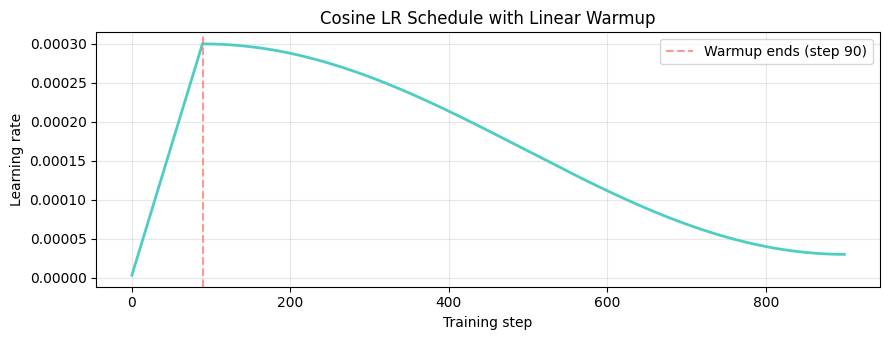

Total steps: 900  |  Warmup steps: 90


In [13]:
def cosine_lr_with_warmup(step, total_steps, peak_lr, warmup_steps, min_lr_ratio=0.1):
    """Linear warmup then cosine decay. Returns LR at this step."""
    if step < warmup_steps:
        # Linear warmup: 0 → peak_lr over `warmup_steps`
        return peak_lr * (step + 1) / warmup_steps
    # Cosine decay: peak_lr → min_lr
    progress = (step - warmup_steps) / max(1, total_steps - warmup_steps)
    progress = min(progress, 1.0)
    min_lr = peak_lr * min_lr_ratio
    return min_lr + 0.5 * (peak_lr - min_lr) * (1 + math.cos(math.pi * progress))

# Preview the LR schedule we are about to use
NUM_EPOCHS = 50
steps_per_epoch = len(train_loader)
total_steps     = NUM_EPOCHS * steps_per_epoch
warmup_steps    = max(1, total_steps // 10)  # 10% warmup

lrs = [cosine_lr_with_warmup(s, total_steps, PEAK_LR, warmup_steps) for s in range(total_steps)]

plt.figure(figsize=(9, 3.5))
plt.plot(lrs, linewidth=2, color="#4ECDC4")
plt.axvline(warmup_steps, linestyle="--", color="#FF6B6B", alpha=0.7, label=f"Warmup ends (step {warmup_steps})")
plt.xlabel("Training step")
plt.ylabel("Learning rate")
plt.title("Cosine LR Schedule with Linear Warmup")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Total steps: {total_steps}  |  Warmup steps: {warmup_steps}")

---

## 8. The Training Loop

The core training loop is remarkably short — only a few lines. Everything else in this notebook is plumbing around it.

```
for batch in loader:
    logits = model(x)                         # forward
    loss   = cross_entropy(logits, y)         # loss
    optimizer.zero_grad()                     # clear old grads
    loss.backward()                           # backward: compute grads
    clip_grad_norm_(model.parameters(), 1.0)  # gradient clipping
    optimizer.step()                          # update weights
```

We add LR scheduling, periodic validation, and logging. No more, no less.

In [14]:
def train(model, train_loader, val_loader, optimizer, device,
          num_epochs, peak_lr, warmup_steps, grad_clip,
          eval_every=None):
    """Train `model` and return per-step / per-epoch metrics."""
    steps_per_epoch = len(train_loader)
    total_steps     = num_epochs * steps_per_epoch
    eval_every      = eval_every or max(1, steps_per_epoch)  # default: eval once per epoch

    history = {
        "train_loss_step": [],   # loss at each step
        "lr_step":         [],   # LR at each step
        "train_loss_eval": [],   # full train loss, sampled periodically
        "val_loss_eval":   [],   # full val loss, sampled periodically
        "eval_steps":      [],   # global step where each eval happened
    }

    global_step = 0
    model.train()

    for epoch in range(num_epochs):
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)

            # 1. Set LR for this step
            lr = cosine_lr_with_warmup(global_step, total_steps, peak_lr, warmup_steps)
            for pg in optimizer.param_groups:
                pg["lr"] = lr

            # 2. Forward + loss
            loss = compute_loss(model, x, y)

            # 3. Backward + clip + step
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
            optimizer.step()

            history["train_loss_step"].append(loss.item())
            history["lr_step"].append(lr)

            # 4. Periodic evaluation
            if (global_step + 1) % eval_every == 0 or global_step == total_steps - 1:
                train_loss_full = evaluate(model, train_loader, device)
                val_loss_full   = evaluate(model, val_loader, device)
                history["train_loss_eval"].append(train_loss_full)
                history["val_loss_eval"].append(val_loss_full)
                history["eval_steps"].append(global_step + 1)
                print(
                    f"  step {global_step + 1:4d} / {total_steps}  |  "
                    f"lr {lr:.5f}  |  "
                    f"train loss {train_loss_full:.3f}  "
                    f"(ppl {math.exp(train_loss_full):6.1f})  |  "
                    f"val loss {val_loss_full:.3f}  "
                    f"(ppl {math.exp(val_loss_full):6.1f})"
                )

            global_step += 1

    return history

### 8.1 Run Training

The output below is the standard LM training readout: for each epoch we report the current LR, the full-dataset train loss, the validation loss, and perplexity. The random-init baseline is around **11.0** (perplexity near the 50,257-token vocabulary size). Over 50 epochs / 900 optimizer steps, training loss drops to roughly **3.2** (perplexity ~25), while validation loss plateaus around **6.0** (perplexity ~430). That gap is expected: on a 5,145-token corpus a 13.7 M-parameter model has more than enough capacity to memorize, so the validation curve flattens long before the training curve does.

In [15]:
print(f"Training for {NUM_EPOCHS} epochs ({total_steps} steps total)...\n")

history = train(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    device=DEVICE,
    num_epochs=NUM_EPOCHS,
    peak_lr=PEAK_LR,
    warmup_steps=warmup_steps,
    grad_clip=GRAD_CLIP,
    eval_every=steps_per_epoch,  # evaluate once per epoch
)

print("\nDone.")

Training for 50 epochs (900 steps total)...

  step   18 / 900  |  lr 0.00006  |  train loss 10.866  (ppl 52352.7)  |  val loss 10.908  (ppl 54596.0)
  step   36 / 900  |  lr 0.00012  |  train loss 10.409  (ppl 33155.6)  |  val loss 10.495  (ppl 36150.9)
  step   54 / 900  |  lr 0.00018  |  train loss 9.771  (ppl 17511.2)  |  val loss 9.890  (ppl 19735.9)
  step   72 / 900  |  lr 0.00024  |  train loss 9.011  (ppl 8192.8)  |  val loss 9.191  (ppl 9811.5)
  step   90 / 900  |  lr 0.00030  |  train loss 8.069  (ppl 3194.1)  |  val loss 8.352  (ppl 4238.8)
  step  108 / 900  |  lr 0.00030  |  train loss 7.186  (ppl 1320.3)  |  val loss 7.572  (ppl 1943.0)
  step  126 / 900  |  lr 0.00030  |  train loss 6.553  (ppl  701.0)  |  val loss 7.039  (ppl 1140.0)
  step  144 / 900  |  lr 0.00030  |  train loss 6.149  (ppl  468.3)  |  val loss 6.730  (ppl  837.4)
  step  162 / 900  |  lr 0.00029  |  train loss 5.891  (ppl  361.7)  |  val loss 6.565  (ppl  709.9)
  step  180 / 900  |  lr 0.00029  | 

---

## 9. Loss and Perplexity Curves

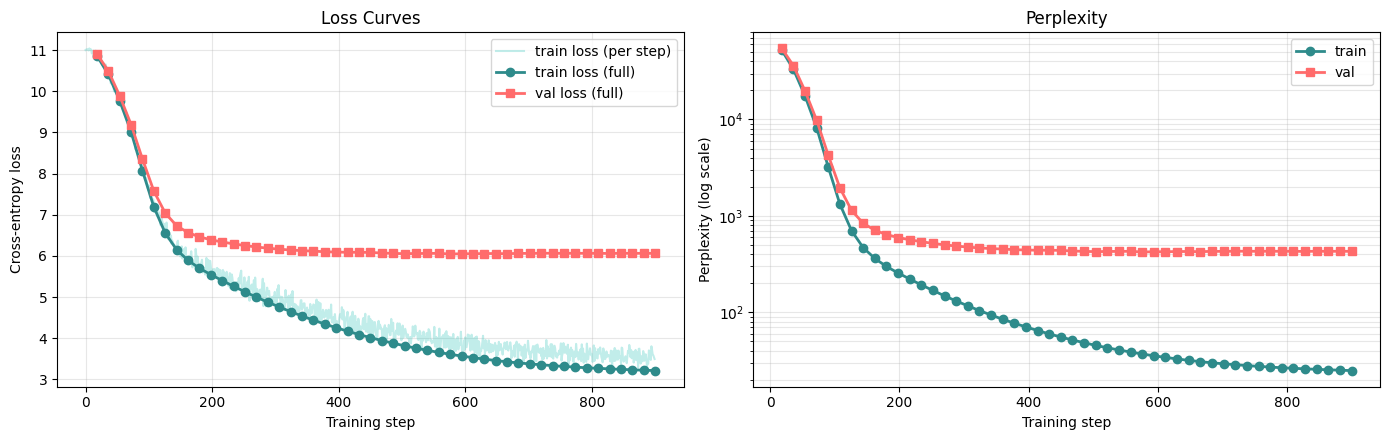

Final train loss: 3.211  (ppl 24.8)
Final val   loss: 6.061  (ppl 428.6)


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# Left: per-step training loss (noisy) + epoch-level train/val loss
ax = axes[0]
ax.plot(history["train_loss_step"], alpha=0.35, color="#4ECDC4", label="train loss (per step)")
ax.plot(history["eval_steps"], history["train_loss_eval"], "o-",
        color="#2E8B8B", label="train loss (full)", linewidth=2)
ax.plot(history["eval_steps"], history["val_loss_eval"], "s-",
        color="#FF6B6B", label="val loss (full)", linewidth=2)
ax.set_xlabel("Training step")
ax.set_ylabel("Cross-entropy loss")
ax.set_title("Loss Curves")
ax.legend()
ax.grid(alpha=0.3)

# Right: perplexity (log scale)
ax = axes[1]
train_ppl = [math.exp(l) for l in history["train_loss_eval"]]
val_ppl   = [math.exp(l) for l in history["val_loss_eval"]]
ax.plot(history["eval_steps"], train_ppl, "o-", color="#2E8B8B", label="train", linewidth=2)
ax.plot(history["eval_steps"], val_ppl,   "s-", color="#FF6B6B", label="val",   linewidth=2)
ax.set_yscale("log")
ax.set_xlabel("Training step")
ax.set_ylabel("Perplexity (log scale)")
ax.set_title("Perplexity")
ax.legend()
ax.grid(alpha=0.3, which="both")

plt.tight_layout()
plt.show()

final_train = history["train_loss_eval"][-1]
final_val   = history["val_loss_eval"][-1]
print(f"Final train loss: {final_train:.3f}  (ppl {train_ppl[-1]:.1f})")
print(f"Final val   loss: {final_val:.3f}  (ppl {val_ppl[-1]:.1f})")

A few things to look for in these curves:

- **Training loss drops steeply** at first, then flattens — this is the model rapidly learning which tokens appear in the text, followed by slower refinement of *which token comes next given context*.
- **Validation loss drops early alongside training loss but plateaus around epoch 15** and then drifts roughly sideways for the rest of the run. On a larger corpus validation would keep falling for much longer; here, the model has exhausted the generalizable signal in 5,145 tokens and further training mostly memorizes the training half.
- **The train–val gap** widens from near-zero at initialization to roughly 2.8 nats by the end — the signature of overfitting on a small corpus. A 13.7 M-parameter model against 5,145 tokens of training text is a setup that *should* overfit; the gap is evidence the optimization is working, not that something is broken.

---

## 10. Generation: Before vs. After Training

In [17]:
print("=" * 60)
print("BEFORE TRAINING (random-init model)")
print("=" * 60)
print(repr(pre_training_output))
print()

print("=" * 60)
print("AFTER TRAINING")
print("=" * 60)
post_training_output = generate(model, PROMPT, tokenizer, max_new_tokens=30)
print(repr(post_training_output))

BEFORE TRAINING (random-init model)
'It was themaster Cricket slut 244ylene bid restrictivesolesley sworn Amp CV MiscRoot nons Spa proprietary featherintoncmsChrisydBUG imperative evacuation producer greatest fluffy up 214'

AFTER TRAINING
'It was the, one of the house."\n\n"I looked.\n"I turned.\n\n"I looked.\n"I turned.\n"'


The trained model generates very differently from the untrained one. A few things worth noting about what you see above:

- **Greedy decoding loves the most common token.** Early in training the safest bet for lowering cross-entropy is to predict tokens like `the`, `,`, and `.` — they are common and the model gets a reasonable log-prob just by leaning on them. With **greedy** decoding (always `argmax`), this shows up as repetition: `"I looked." "I turned." "I looked." "I turned."` is a classic sign that the model has learned local n-gram structure but is trapped in a cycle by deterministic decoding.
- **The fix is not more training alone — it is better *sampling*.** Temperature, top-k, and top-p sampling break out of these degenerate loops even with the exact same trained weights. That is the subject of the next notebook (`07_inference`).
- **Scale still matters.** Our model has 13.7 M parameters (of which under 1 M are in the transformer blocks) and trained on ~5,000 tokens. GPT-2 small has 124 M parameters trained on ~10 B tokens — roughly 10,000× more data and ~10× more parameters in comparable layers.

### 10.1 A Few Different Prompts

In [18]:
prompts = [
    "The artist",
    "She said",
    "I had always thought",
]

for p in prompts:
    out = generate(model, p, tokenizer, max_new_tokens=25)
    print(f"Prompt:  {p!r}")
    print(f"Output:  {out!r}")
    print()

Prompt:  'The artist'
Output:  'The artist the picture of the fact--as, and he had been Rome a little of the house."\n\n\n"I looked'

Prompt:  'She said'
Output:  'She said, so that he had been Rome, and as he had been Rome, and as he had been Rome he had been Rome'

Prompt:  'I had always thought'
Output:  'I had always thought him--as, the Riv, and Mrs. Gisburn, and Mrs. Gisburn\'s "Be to have'



---

## 11. Saving and Loading Checkpoints

In any real training run you want to **save checkpoints** — at minimum, the final weights, and typically the best-val-loss weights too. In production runs you also save the optimizer state and the step/epoch number so training can be resumed after interruption.

Below we save everything needed to reload the trained model and continue from where we left off.

In [19]:
CHECKPOINT_PATH = "gpt_decoder_trained.pt"

checkpoint = {
    "model_state_dict":     model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    "config": {
        "vocab_size":  VOCAB_SIZE,
        "d_model":     D_MODEL,
        "num_heads":   NUM_HEADS,
        "d_ff":        D_FF,
        "num_layers":  NUM_LAYERS,
        "max_len":     MAX_LEN,
        "dropout":     DROPOUT,
    },
    "history": history,
}

torch.save(checkpoint, CHECKPOINT_PATH)
size_mb = os.path.getsize(CHECKPOINT_PATH) / (1024 ** 2)
print(f"Saved checkpoint to {CHECKPOINT_PATH}  ({size_mb:.1f} MB)")

Saved checkpoint to gpt_decoder_trained.pt  (157.1 MB)


In [20]:
# Demonstrate loading: build a fresh model from the saved config, load weights,
# and confirm it generates the same output as the live model.
loaded = torch.load(CHECKPOINT_PATH, map_location=DEVICE)
cfg = loaded["config"]

restored_model = GPTDecoder(**cfg).to(DEVICE)
restored_model.load_state_dict(loaded["model_state_dict"])
restored_model.eval()

out_original = generate(model,          PROMPT, tokenizer, max_new_tokens=20)
out_restored = generate(restored_model, PROMPT, tokenizer, max_new_tokens=20)

print("Original model:  ", repr(out_original))
print("Restored model:  ", repr(out_restored))
print("Outputs match:   ", out_original == out_restored)

/var/folders/xg/pf411g390wqfjs0pn97zr8cw0000gn/T/ipykernel_99182/2724115021.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  loaded = torch.load(CHECKPOINT_PATH, map_loca

Original model:   'It was the, one of the house."\n\n"I looked.\n"I turned.\n\n"'
Restored model:   'It was the, one of the house."\n\n"I looked.\n"I turned.\n\n"'
Outputs match:    True


---

## 12. Key Takeaways

- The **training loop itself is tiny** — forward, loss, backward, clip, step. Everything else is plumbing.
- **Cross-entropy loss** at each position is the standard LM objective; **perplexity** is the exponential of that loss and is easier to interpret. On this run we moved from loss 11.02 (ppl ~61k) to loss 3.21 (ppl ~25) on the training set.
- **AdamW** with `betas=(0.9, 0.95)` and `weight_decay=0.1` is the GPT-style default. **Cosine decay with warmup** (90 warmup steps out of 900 total) and **gradient clipping** at 1.0 are near-universal in transformer training.
- **Train/val split** lets you detect overfitting — especially important on small corpora. Our validation perplexity plateaued at ~430 while training perplexity kept falling, which is exactly the overfitting signature we would expect with 13.7 M parameters against 5,145 tokens.
- **A small GPT trained on the-verdict.txt** demonstrates every mechanical part of real LM training: it just needs more data, more parameters, and more compute to become a usable model.
- The **checkpoint** contains enough state (weights + optimizer + config) to resume training or use the trained model in another notebook.

### What's next
With a trained model in hand, we can now explore **inference-time techniques** — temperature, top-k, top-p, beam search — that shape *how* the model generates text. That is the focus of the next notebook.